In [1]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
print(path)

c:\Users\bryan\Documents\Github\Repositories\Leaf-Disease-Detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\bryan\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1


In [2]:
import os

for root, dirs, files in os.walk(path):
    print(root, "=", len(dirs), "folders, ", len(files), "files")
    if len(files) > 0:
        break

C:\Users\bryan\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1 = 1 folders,  0 files
C:\Users\bryan\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage = 15 folders,  0 files
C:\Users\bryan\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage\Pepper__bell___Bacterial_spot = 0 folders,  997 files


In [3]:
data_dir = os.path.join(path, "PlantVillage")

for folder in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder)
    n_files = len(os.listdir(folder_path))
    print(f"{n_files:5d}  {folder}")

  997  Pepper__bell___Bacterial_spot
 1478  Pepper__bell___healthy
 1000  Potato___Early_blight
 1000  Potato___Late_blight
  152  Potato___healthy
 2127  Tomato_Bacterial_spot
 1000  Tomato_Early_blight
 1909  Tomato_Late_blight
  952  Tomato_Leaf_Mold
 1771  Tomato_Septoria_leaf_spot
 1676  Tomato_Spider_mites_Two_spotted_spider_mite
 1404  Tomato__Target_Spot
 3209  Tomato__Tomato_YellowLeaf__Curl_Virus
  373  Tomato__Tomato_mosaic_virus
 1591  Tomato_healthy


In [4]:
import shutil

dup = os.path.join(data_dir, "PlantVillage")
if os.path.exists(dup):
    shutil.rmtree(dup)
    print("Removed duplicate folder")

print(len(os.listdir(data_dir)), "classes")

15 classes


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

full_data = datasets.ImageFolder(data_dir, transform = transform)

print(len(full_data), "images")
print(full_data.classes)

20638 images
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
train_size = int(0.8 * len(full_data))
test_size = len(full_data) - train_size

generator = torch.Generator().manual_seed(42)
train_data, test_data = random_split(full_data, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 32)

print(len(train_data), len(test_data))

16510 4128


80/20 split
Batch size is smaller than mnist because images are way bigger and takes up more GPU memory.

torch.Size([32, 3, 128, 128])


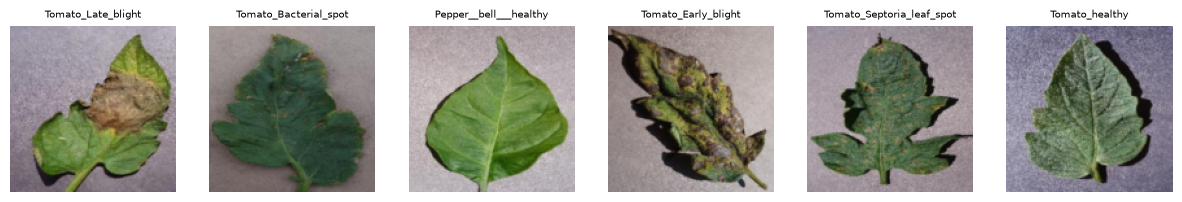

In [7]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print(images.shape)

fig, axes = plt.subplots(1, 6, figsize = (15, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].permute(1,2,0))
    ax.set_title(full_data.classes[labels[i]], fontsize = 7)
    ax.axis("off")
plt.show()

squeeze() remove size-1 dimensions
permute() reorders dimension

In [8]:
import torch.nn as nn

class LeafCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),


        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
device = "cuda"
model = LeafCNN(num_classes= len(full_data.classes)).to(device)


In [9]:
x = images.to(device)
print("input", x.shape)

for layer in model.features:
    x = layer(x)
    print(f"{layer.__class__.__name__:10s} {tuple(x.shape)}")
print("output:", model(images.to(device)).shape)

input torch.Size([32, 3, 128, 128])
Conv2d     (32, 16, 128, 128)
ReLU       (32, 16, 128, 128)
MaxPool2d  (32, 16, 64, 64)
Conv2d     (32, 32, 64, 64)
ReLU       (32, 32, 64, 64)
MaxPool2d  (32, 32, 32, 32)
Conv2d     (32, 64, 32, 32)
ReLU       (32, 64, 32, 32)
MaxPool2d  (32, 64, 16, 16)
output: torch.Size([32, 15])


In [10]:
from tqdm import tqdm

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc = "Training"):
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        loss = loss_fn(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim = 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [11]:
epochs = 10

for epoch in range(epochs):
    loss = train_one_epoch(model, train_loader)
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch + 1}: loss {loss:.3f}, train acc {train_acc:.2%} | test acc {test_acc:.2%}")

Training: 100%|██████████| 516/516 [00:27<00:00, 19.05it/s]


Epoch 1: loss 1.222, train acc 78.82% | test acc 77.74%


Training: 100%|██████████| 516/516 [00:19<00:00, 26.75it/s]


Epoch 2: loss 0.556, train acc 88.32% | test acc 86.19%


Training: 100%|██████████| 516/516 [00:20<00:00, 24.76it/s]


...

Epoch 8: loss 0.102, train acc 98.14% | test acc 91.76%


Training: 100%|██████████| 516/516 [00:19<00:00, 26.84it/s]


Epoch 9: loss 0.086, train acc 98.35% | test acc 92.01%


Training: 100%|██████████| 516/516 [00:20<00:00, 25.40it/s]


Epoch 10: loss 0.081, train acc 98.59% | test acc 92.18%


To prevent overfitting, we are going to randomly flip, roatte, tweak the colors of training image each time they're loaded. The model never sees the exact same photo twice, so it can't memorize. It has to learn what a disease actually looks like.

In [12]:
from torch.utils.data import Subset

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_full = datasets.ImageFolder(data_dir, transform = train_transform)
test_full = datasets.ImageFolder(data_dir, transform = test_transform)

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_full), generator = generator).tolist()
train_data = Subset(train_full, indices[:train_size])
test_data = Subset(test_full, indices[train_size:])

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 32)

In [13]:
model = LeafCNN(num_classes = len(full_data.classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(10):
    loss = train_one_epoch(model, train_loader)
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: loss {loss:.3f} | train acc {train_acc:.2%} | test acc {test_acc:.2%}")

Training:   0%|          | 0/516 [00:00<?, ?it/s]

Training: 100%|██████████| 516/516 [00:29<00:00, 17.62it/s]


Epoch 1: loss 1.564 | train acc 70.19% | test acc 73.26%


Training: 100%|██████████| 516/516 [00:27<00:00, 18.82it/s]


Epoch 2: loss 0.826 | train acc 78.59% | test acc 80.98%


...

Epoch 8: loss 0.341 | train acc 88.79% | test acc 90.48%


Training: 100%|██████████| 516/516 [00:28<00:00, 18.36it/s]


Epoch 9: loss 0.312 | train acc 91.33% | test acc 91.69%


Training: 100%|██████████| 516/516 [00:29<00:00, 17.45it/s]


Epoch 10: loss 0.286 | train acc 91.80% | test acc 92.66%


In [15]:
#re run it for another 10 times without restarting the model
for epoch in range(10):
    loss = train_one_epoch(model, train_loader)
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}: loss {loss:.3f} | train acc {train_acc:.2%} | test acc {test_acc:.2%}")

Training: 100%|██████████| 516/516 [00:27<00:00, 18.58it/s]


Epoch 1: loss 0.167 | train acc 93.05% | test acc 92.93%


Training: 100%|██████████| 516/516 [00:30<00:00, 17.01it/s]


Epoch 2: loss 0.160 | train acc 95.18% | test acc 94.45%


Training: 100%|██████████| 516/516 [00:30<00:00, 17.15it/s]


...

Epoch 8: loss 0.135 | train acc 92.08% | test acc 91.09%


Training: 100%|██████████| 516/516 [00:29<00:00, 17.55it/s]


Epoch 9: loss 0.141 | train acc 95.37% | test acc 93.73%


Training: 100%|██████████| 516/516 [00:29<00:00, 17.46it/s]


Epoch 10: loss 0.130 | train acc 96.83% | test acc 95.08%


In [18]:
os.makedirs("../models", exist_ok = True)
torch.save(model.state_dict(), "../models/cnn_scratch.pth")
print("Saved")

Saved
